### <font color = "gold"> Import les librairies requises

In [1]:
# Importer les packages
import pandas as pd
import numpy as np
import plotly.express as px

Mounted at /content/drive


In [2]:
 # Supprimer les warnings
 import warnings
 warnings.filterwarnings('ignore')

### <font color = "gold"> Importer et lire les données

In [3]:
# Importer les données
df= pd.read_csv('data/wheat_seeds_dataset.csv')
df.head()

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


**Nous avons ici des données de graines de blé. Chaque graine de blé est caractérisée par 7 variables morphologiques (issues de l'étude morphologique de chaque graine).**

In [4]:
# Afficher les données
df.head( )

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [5]:
# Dimension des données
df.shape

(199, 7)

In [6]:
# Infos des données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area A                   199 non-null    float64
 1   perimeter                199 non-null    float64
 2   compactness              199 non-null    float64
 3   length of kernel         199 non-null    float64
 4   width of kernel          199 non-null    float64
 5   asymmetry coefficient    199 non-null    float64
 6   length of kernel groove  199 non-null    float64
dtypes: float64(7)
memory usage: 11.0 KB


In [7]:
# Décrire les données
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area A,199.0,14.918744,2.919976,10.5900,12.3300,14.4300,17.4550,21.1800
perimeter,199.0,14.595829,1.310445,12.4100,13.4700,14.3700,15.8050,17.2500
compactness,199.0,0.870811,0.023320,0.8081,0.8571,0.8734,0.8868,0.9183
length of kernel,199.0,5.643151,0.443593,4.8990,5.2670,5.5410,6.0020,6.6750
width of kernel,199.0,3.265533,0.378322,2.6300,2.9545,3.2450,3.5645,4.0330
asymmetry coefficient,199.0,3.699217,1.471102,0.7651,2.5700,3.6310,4.7990,8.3150
length of kernel groove,199.0,5.420653,0.492718,4.5190,5.0460,5.2280,5.8790,6.5500


In [8]:
# Renommer les index
for i in range(len(df)):
  df.rename(index={i: 'graine' + str(i+1)}, inplace= True )
#Afficher df
df.head()

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
graine1,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
graine2,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
graine3,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
graine4,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
graine5,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [9]:
# Matrice des données
x = df.values
x[:5]

array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ]])

In [10]:
# Importer normalize
from sklearn.preprocessing import normalize
# Normaliser x
x = normalize(x)
x[:5]

array([[0.66271789, 0.64447795, 0.03782617, 0.25027806, 0.14383497,
        0.09645455, 0.22669642],
       [0.66410726, 0.65027169, 0.03932425, 0.24787982, 0.14875467,
        0.04543422, 0.22119056],
       [0.65688362, 0.64769001, 0.0416011 , 0.24321702, 0.15339543,
        0.1240678 , 0.2217959 ],
       [0.64909686, 0.65378687, 0.04199901, 0.24969593, 0.15847531,
        0.10594724, 0.2253548 ],
       [0.68244585, 0.63382053, 0.03819836, 0.23923659, 0.15061166,
        0.05729332, 0.21881396]])

#### <font color = "gold"> Appliquer une ACP

In [11]:
# Importer PCA
from sklearn.decomposition import PCA
#Instantier le modèle PCA avec n_components = 2
pca = PCA(n_components= 2)

# Matrice des 2 composantes
features_pca= pca.fit_transform(x)
# Dataframe
df_pca = pd.DataFrame(features_pca, columns = ['PC 1', 'PC 2'])
df_pca.head()

,PC 1,PC 2
0,-0.067442,-0.023518
1,-0.111858,-0.048880
2,-0.041865,-0.013449
3,-0.051821,-0.032872
4,-0.113844,-0.020598


In [12]:
# Part de variance des 2 composantes
print(round(sum(pca.explained_variance_ratio_*100),2), '%')

98.55 %


### <font color = "gold"> Kmeans

In [13]:
# Importer KMeans
from sklearn.cluster import KMeans

In [14]:
# rechercher le k optimal
inertia = []
for k in range(2, 11):
  # Instantier le modèle kmeans
  kmeans_model = KMeans(n_clusters= k,init = 'random', max_iter=500)
  kmeans_model.fit(x)
  # Rajouter le inertia sur liste inertia
  inertia.append(kmeans_model.inertia_)

In [15]:
# #
# for i in range(2,11):
#   print(f'K = {i} --- Inertia : {inertia[i-2]}')
#   print('------------------------------')
# visualiser le elbow
import plotly.express as px
fig = px.line(x = list(range(2, 11)), y = inertia)
fig.show()

##### <font color = "bisque"> La méthode elbow(coude)

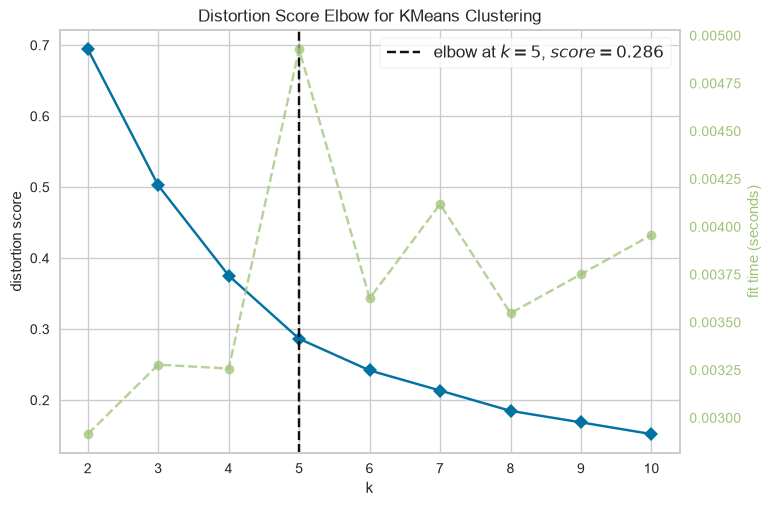

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [16]:
# importer KELbowVisualizer
from yellowbrick.cluster import KElbowVisualizer
# Instantier le modèle kmeans
kmeans_model = KMeans(init = 'random', max_iter=500)
# Instantier KELbowVisualizer
Elbow_M = KElbowVisualizer(kmeans_model, k=10)
# Entrainement
Elbow_M.fit(x)
# Visualiser l'elbow
Elbow_M.show()

#### <font color = "bisque"> Appliquer Kmeans en utilisant le k optimal

In [17]:
# Initier le modèle
kmeans_model = KMeans(n_clusters = 5, init= 'random', max_iter = 500)
# Entrainer le modèle
kmeans_model.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",500
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 7)","[[

#### <font color = "bisque"> Prédiction la partition

In [18]:
# Prediction de la partition(l'ensemble des classes) de X
kmeans_partition = kmeans_model.predict(x)
# Afficher la partition
kmeans_partition

array([3, 3, 3, 3, 2, 3, 0, 2, 2, 0, 3, 0, 3, 3, 0, 0, 2, 3, 1, 3, 3, 2,
       3, 3, 2, 1, 3, 3, 1, 3, 0, 1, 3, 3, 3, 2, 3, 4, 3, 3, 3, 0, 3, 3,
       3, 3, 3, 3, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 3, 3, 1,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2,
       2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0,
       2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 3,
       3, 0, 4, 4, 4, 4, 1, 4, 3, 1, 1, 4, 4, 4, 1, 1, 1, 4, 1, 1, 1, 4,
       1, 1, 4, 1, 4, 3, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 3, 4, 1, 1, 4, 4,
       1, 4, 1, 4, 4, 4, 1, 1, 4, 1, 1, 4, 1, 1, 3, 4, 1, 1, 1, 1, 4, 1,
       4], dtype=int32)

In [19]:
# Nombre d'observations dans chaque classe
val_cluster = pd.Series(kmeans_partition).value_counts()
val_cluster

3    47
0    42
2    40
1    38
4    32
Name: count, dtype: int64

In [20]:
# Diagramme en barre du nombre d'observations dans chaque
fig= px.bar(x = val_cluster.index, y =val_cluster.values, color= val_cluster.index.astype(str), text_auto =True)
fig.show()

#### <font color = "bisque"> Visualiser les classes prédictes par Kmeans

In [21]:
# Visualiser les classes suivant les deux composantes en utilisant plotly.express
fig = px.scatter(df_pca, x = 'PC 1', y = 'PC 2', color = kmeans_partition.astype(str))
fig.show()

<font color = "bisque">Indice de silhouette value de la partition du Kmeans

In [22]:
# Importer silhouette score
from sklearn.metrics import silhouette_score
# Indice de Silhouette value
sil_kmeans = silhouette_score(x, kmeans_partition)
print(f"La silhouette est : {sil_kmeans: .2f}")

La silhouette est :  0.38


In [23]:
# Les graines de chaque classes
clusters_list = []
for i in range(4):
  clusters_list.append(list(df.index[kmeans_partition == i]))

In [24]:
# Afficher les graines de la classe 0
print(clusters_list[3])

['graine1', 'graine2', 'graine3', 'graine4', 'graine6', 'graine11', 'graine13', 'graine14', 'graine18', 'graine20', 'graine21', 'graine23', 'graine24', 'graine27', 'graine28', 'graine30', 'graine33', 'graine34', 'graine35', 'graine37', 'graine39', 'graine40', 'graine41', 'graine43', 'graine44', 'graine45', 'graine46', 'graine47', 'graine48', 'graine52', 'graine53', 'graine54', 'graine55', 'graine56', 'graine57', 'graine58', 'graine59', 'graine62', 'graine63', 'graine64', 'graine65', 'graine132', 'graine133', 'graine141', 'graine160', 'graine171', 'graine191']


### <font color = "gold"> CAH

In [25]:
# Importer linkage et dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram

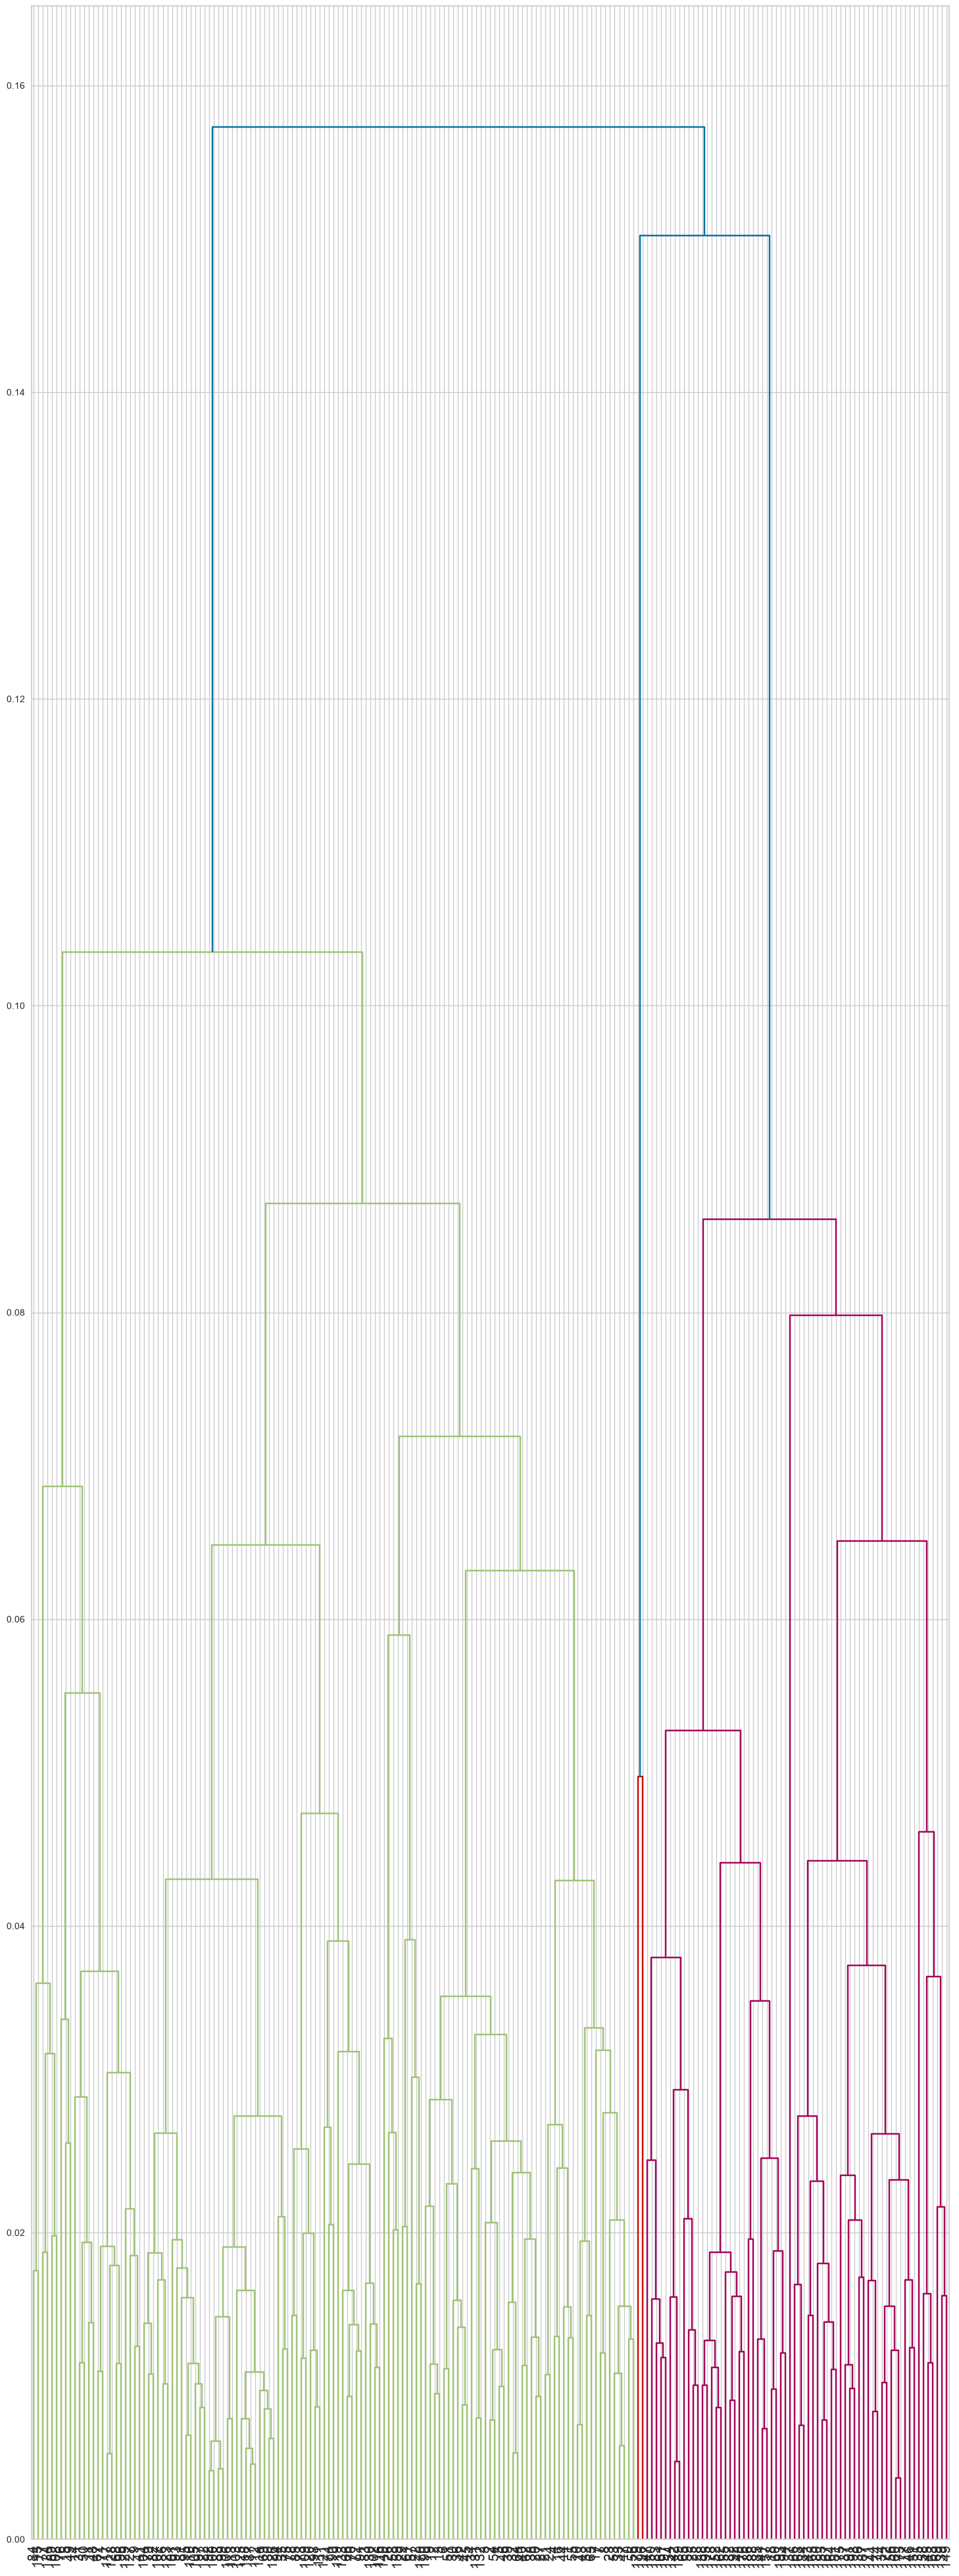

In [26]:
# Visualiser le dendrogramme
import matplotlib.pyplot as plt
Z = linkage(x, 'average')  # matrice des liaisons
plt.figure(figsize=(18, 50))
dendro = dendrogram(Z, leaf_font_size=15, orientation='top')

#### <font color = "bisque"> Appliquer la CAH

In [27]:
# Importer AgglomerativeClustering
from sklearn.cluster import AgglomerativeClustering
# Initier le modèle
cah_model = AgglomerativeClustering(n_clusters=2, linkage='average')
# Entrainer le modèle
cah_model.fit(x)

,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'average'
,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sa

#### <font color = "bisque"> Prédiction la partition

In [28]:
# Prédire la partition des données
cah_partition = cah_model.fit_predict(x)
# Afficher la partition
cah_partition

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0])

In [29]:
# Nombre d'observations dans chaque classe
val_cah = pd.Series(cah_partition).value_counts()
val_cah

1    131
0     68
Name: count, dtype: int64

In [30]:
# Diagramme en barre du nombre d'observations dans chaque classe
fig = px.bar(x=val_cah.index, y=val_cah.values, color=val_cah.index.astype(str), text_auto=True)
fig.show()

#### <font color = "bisque"> Visualiser les classes prédites par la CAH

In [31]:
# Visualiser les classes suivant les deux composantes en utilisant plotly.express
fig = px.scatter(df_pca, x='PC 1', y='PC 2', color=cah_partition.astype(str))
fig.show()

<font color = "bisque">Indice de silhouette de la partition de la CAH

In [32]:
# Indice de Silhouette value
sil_cah = silhouette_score(x, cah_partition)
print(f"La silhouette est : {sil_cah: .2f}")

La silhouette est :  0.48


### <font color = "gold"> DBSCAN

In [33]:
# Importer le modèle DBSCAN
from sklearn.cluster import DBSCAN

##### <font color = "bisque"> Recherche des paramètres optimaux

In [34]:
# Recherche des paramètres optimaux
from outils.utils import eps_min_sam_opt
# Faire appel à la fonction eps_min_sam_opt
eps_min_sam_opt(x)

EPS: 0.05 min_samples : 5
EPS: 0.08750000000000001 min_samples : 5
EPS: 0.125 min_samples : 5
EPS: 0.16250000000000003 min_samples : 5
EPS: 0.2 min_samples : 5
EPS: 0.05 min_samples : 6
EPS: 0.08750000000000001 min_samples : 6
EPS: 0.125 min_samples : 6
EPS: 0.16250000000000003 min_samples : 6
EPS: 0.2 min_samples : 6
EPS: 0.05 min_samples : 7
EPS: 0.08750000000000001 min_samples : 7
EPS: 0.125 min_samples : 7
EPS: 0.16250000000000003 min_samples : 7
EPS: 0.2 min_samples : 7
EPS: 0.05 min_samples : 8
EPS: 0.08750000000000001 min_samples : 8
EPS: 0.125 min_samples : 8
EPS: 0.16250000000000003 min_samples : 8
EPS: 0.2 min_samples : 8
EPS: 0.05 min_samples : 9
EPS: 0.08750000000000001 min_samples : 9
EPS: 0.125 min_samples : 9
EPS: 0.16250000000000003 min_samples : 9
EPS: 0.2 min_samples : 9


In [35]:
# Instantier le modèle avec eps = 0.025 et min_samples = 8
dbscan_model = DBSCAN(eps=0.025, min_samples=8)
# Entrainer le modèle
dbscan_model.fit(x)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.025
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",8
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](113, 7)","[[0.66,0.64,0.04,...,0.14,0.1 ,0.23], [0.66,0.65,0.04,...,0.15,0.12,0.22], [0.65,0.65,0.04,...,0.16,0.11,0.23], ..., [0.61,0.66,0.04,...,0.15,0.19,0.25], [0.58,0.67,0.04,...,0.15,0.22,0.26], [0.6 ,0.67,0.04,...,0.14,0.18,0.26]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](113,)","[ 0, 2, 3,...,193,195,197]"


#### <font color = "bisque"> Prédiction la partition

In [36]:
# Prédire la partition
dbscan_partition = dbscan_model.labels_
# Afficher la partition
dbscan_partition

array([ 0, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  1,  0,  0, -1, -1,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0, -1,  0, -1, -1,  1,  0, -1,  0,  0,  0,  1,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
       -1,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  1, -1,
        1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  0,  1,  1,  1,  1,  1, -1,  1,  1])

In [37]:
# Nombre d'observations dans chaque classe
val_dbscan = pd.Series(dbscan_partition).value_counts()
val_dbscan

 0    109
 1     55
-1     35
Name: count, dtype: int64

In [38]:
# Diagramme en barre du nombre d'observations dans chaque classe
fig = px.bar(x=val_dbscan.index, y=val_dbscan.values, color=val_dbscan.index.astype(str), text_auto=True)
fig.show()

In [39]:
# Visualiser les classes (-1 = anomalie)
fig = px.scatter(df_pca, x='PC 1', y='PC 2', color=dbscan_partition.astype(str))
fig.show()

In [40]:
# Les graines considérées comme des anomalies
anomalies = df.index[dbscan_partition == -1]
anomalies

Index(['graine2', 'graine5', 'graine16', 'graine22', 'graine23', 'graine25',
       'graine30', 'graine38', 'graine50', 'graine56', 'graine58', 'graine59',
       'graine62', 'graine77', 'graine78', 'graine79', 'graine85', 'graine90',
       'graine109', 'graine116', 'graine120', 'graine125', 'graine130',
       'graine136', 'graine140', 'graine141', 'graine146', 'graine155',
       'graine159', 'graine160', 'graine164', 'graine171', 'graine180',
       'graine189', 'graine197'],
      dtype='str')

In [41]:
# Partition sans les anomalies (-1)
partition_sans_anomalies = dbscan_partition[dbscan_partition != -1]
# Dataframe sans les anomalies
df_sans_anomalies = df[dbscan_partition != -1]
# df_pca sans anomalies
df_pca_sans_anomalies = df_pca[dbscan_partition != -1]
# La matrice sans anomalies
x_sans_anomalies = x[dbscan_partition != -1]

In [42]:
# Visualiser les classes sans les anomalies
fig = px.scatter(df_pca_sans_anomalies, x='PC 1', y='PC 2', color=partition_sans_anomalies.astype(str))
fig.show()

<font color = "bisque">Indice de silhouette de la partition finale du DBSCAN

In [43]:
# Indice de Silhouette value de la partition finale (sans anomalies)
sil_dbscan = silhouette_score(x_sans_anomalies, partition_sans_anomalies)
print(f"La silhouette est : {sil_dbscan: .2f}")

La silhouette est :  0.54


### <font color = "gold"> Comparaison des modèles

In [44]:
# Diagramme en barre des indices de silhouette des 3 modèles
noms_modeles = ['KMEANS', 'CAH', 'DBSCAN']
silhouettes = [sil_kmeans, sil_cah, sil_dbscan]
fig = px.bar(x=noms_modeles, y=silhouettes, color=noms_modeles, text_auto=True)
fig.show()

**Le DBSCAN obtient le meilleur indice de silhouette : c'est ce modèle que nous allons déployer.**

In [45]:
# Les graines de chaque classe (partition du DBSCAN, sans les anomalies)
graines_par_classe = []
for k in range(2):
  graines_par_classe.append(list(df_sans_anomalies.index[partition_sans_anomalies == k]))

In [46]:
# Les graines de la classe 0
graines_par_classe[0][:10]

['graine1',
 'graine3',
 'graine4',
 'graine6',
 'graine7',
 'graine8',
 'graine9',
 'graine10',
 'graine11',
 'graine12']

In [47]:
# Les graines de la classe 1
graines_par_classe[1][:10]

['graine19',
 'graine60',
 'graine66',
 'graine135',
 'graine137',
 'graine138',
 'graine139',
 'graine142',
 'graine143',
 'graine144']

---

### <font color = "gold"> Déploiement du meilleur modèle (DBSCAN)

La comparaison des indices de silhouette montre que **DBSCAN** fournit la meilleure partition.
C'est donc ce modèle que nous allons déployer.

**Objectif du déploiement** : saisir les caractéristiques d'une **nouvelle graine de blé** et obtenir automatiquement la **classe** à laquelle elle appartient (parmi les classes de la partition).

#### <font color = "bisque"> 1. Comprendre le problème : DBSCAN n'a pas de méthode `predict()`

Avec KMeans, on peut écrire `kmeans_model.predict(nouvelle_graine)` : chaque classe possède un centre, il suffit de trouver le centre le plus proche.

DBSCAN, lui, **ne calcule pas de centres**. Il n'a donc pas de méthode `predict()` : il sait seulement classer les points qu'il a vus pendant l'entraînement (`dbscan_model.labels_`).

**La solution, très simple** : DBSCAN mémorise les **points cœur** (les points denses autour desquels les classes se sont formées). Ils sont stockés dans `dbscan_model.components_`.
Pour une nouvelle graine, on applique exactement la règle de DBSCAN :

1. on cherche le **point cœur le plus proche** de la nouvelle graine ;
2. si la distance est **inférieure ou égale à `eps`**, la graine prend la classe de ce point cœur ;
3. sinon, la graine est une **anomalie** (classe -1).

#### <font color = "bisque"> 2. Récupérer les points cœur de DBSCAN

In [48]:
# Les points cœur mémorisés par DBSCAN
points_coeur = dbscan_model.components_
# La classe de chacun de ces points cœur
labels_coeur = dbscan_model.labels_[dbscan_model.core_sample_indices_]

print("Nombre de points cœur :", len(points_coeur))
print("Classes présentes      :", np.unique(labels_coeur))

Nombre de points cœur : 113
Classes présentes      : [0 1]


#### <font color = "bisque"> 3. La fonction de prédiction

Attention : le modèle a été entraîné sur les données **normalisées** (`x = normalize(x)`).
Il faut donc appliquer **exactement le même prétraitement** à la nouvelle graine.

`normalize()` traite chaque ligne indépendamment des autres (elle divise chaque ligne par sa norme). On peut donc normaliser une graine seule, sans avoir besoin des données d'entraînement.

In [49]:
def predire_classe(nouvelle_graine):

    # Mettre la graine sous forme de matrice à 1 ligne, puis la normaliser
    graine = np.array(nouvelle_graine, dtype=float).reshape(1, -1)
    graine = normalize(graine)

    # Distances entre la graine et tous les points cœur
    distances = np.linalg.norm(points_coeur - graine, axis=1)

    # Le point cœur le plus proche
    plus_proche = distances.argmin()

    # Règle de DBSCAN : dans le voisinage (eps) ou pas ?
    if distances[plus_proche] <= dbscan_model.eps:
        # classe du point cœur le plus proche
        return labels_coeur[plus_proche]
    else:
        # anomalie
        return -1

In [50]:
# Test rapide
print("Classe prédite  :", predire_classe(df.iloc[0].values))
print("Classe de DBSCAN:", dbscan_partition[0])

Classe prédite  : 0
Classe de DBSCAN: 0


#### <font color = "bisque"> 4. Interpréter les classes

Avant de livrer l'application, il faut savoir **ce que représente chaque classe**, pour afficher un message compréhensible par l'utilisateur final. On regarde le profil moyen de chaque classe.

In [51]:
# Profil moyen de chaque classe (sans les anomalies)
profil = df_sans_anomalies.groupby(partition_sans_anomalies).mean().round(2)
profil

,area A,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
0,16.55,15.33,0.88,5.89,3.48,3.07,5.62
1,11.85,13.25,0.85,5.23,2.84,4.63,5.11


In [52]:
# Noms des classes (d'après le profil moyen : classe 0 = graines plus grandes)
noms_classes = {
    0: "Grosses graines",
    1: "Petites graines",
}

#### <font color = "bisque"> 5. Sauvegarder les artefacts pour le déploiement

L'application finale (Streamlit, fichier `app.py`) a besoin des points cœur, de `eps`, des noms de colonnes et de quelques valeurs par défaut pour pré-remplir le formulaire.

In [53]:
# Sauvegarder tout ce dont l'application aura besoin
import joblib
artefacts = {
    "points_coeur": points_coeur,
    "labels_coeur": labels_coeur,
    "eps": dbscan_model.eps,
    "colonnes": list(df.columns),
    "valeurs_defaut": df.median().tolist(),
    "exemples": df.head(3).values.tolist(),
    "noms_classes": noms_classes,
}

joblib.dump(artefacts, "models/modele_dbscan.joblib")

['models/modele_dbscan.joblib']